In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
x=df.iloc[:,0:8]
y=df["Outcome"]
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [6]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=15)
model=nn.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [7]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=15)
model.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [8]:
diff=pd.DataFrame({"Actual":y_test,"Predicted":prediction})
diff

,Actual,Predicted
285,0,1
101,0,0
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0


In [9]:
# for converting csv file into excel sheet.
# diff.to_excel("diabetes_data.xlsx")

In [10]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)

[[89 10]
 [23 32]]


In [11]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

89 10 23 32


In [12]:
# Accuracy Score
print("Accuracy Score :",(TP+TN)/(TP+TN+FP+FN))

Accuracy Score : 0.7857142857142857


In [13]:
from sklearn.metrics import accuracy_score
print("Accuracy Score :",accuracy_score(y_test,prediction))

Accuracy Score : 0.7857142857142857


In [14]:
# Error Rate
print("Error Rate :",(FP+FN)/(TP+TN+FP+FN))

Error Rate : 0.21428571428571427


In [15]:
# Sensitivity
print("Sensitivity :",(TP)/(TP+FN))

Sensitivity : 0.5818181818181818


In [16]:
from sklearn.metrics import recall_score 
print("Sensitivity :",recall_score(y_test,prediction))

Sensitivity : 0.5818181818181818


In [17]:
from sklearn.metrics import recall_score 
print("Sensitivity :",recall_score(y_test,prediction,pos_label=1))

Sensitivity : 0.5818181818181818


In [18]:
# Specificity
print("Specificity :",(TN)/(TP+FP))

Specificity : 2.119047619047619


In [19]:
from sklearn.metrics import recall_score 
print("Specificity :",recall_score(y_test,prediction,pos_label=0))

Specificity : 0.898989898989899


In [20]:
# Precision Score
print("Precision Score :",(TP)/(TP+FP))

Precision Score : 0.7619047619047619


In [21]:
from sklearn.metrics import precision_score
print("Precision Score :",precision_score(y_test,prediction))

Precision Score : 0.7619047619047619


In [22]:
from sklearn.metrics import precision_score
print("Precision Score :",precision_score(y_test,prediction,pos_label=1))

Precision Score : 0.7619047619047619


In [23]:
from sklearn.metrics import precision_score
print("Precision Score :",precision_score(y_test,prediction,pos_label=0))

Precision Score : 0.7946428571428571


In [24]:
from sklearn.neighbors import KNeighborsClassifier
accuracy=[]
for i in range(1,31):
    nn=KNeighborsClassifier(n_neighbors=i)
    model=nn.fit(x_train,y_train)
    prediction=model.predict(x_test)
    accuracy.append(accuracy_score(y_test,prediction))
print(accuracy)

[0.7207792207792207, 0.7272727272727273, 0.7402597402597403, 0.7207792207792207, 0.7337662337662337, 0.7727272727272727, 0.7597402597402597, 0.7662337662337663, 0.7662337662337663, 0.7597402597402597, 0.7467532467532467, 0.7727272727272727, 0.7662337662337663, 0.7727272727272727, 0.7857142857142857, 0.7857142857142857, 0.7857142857142857, 0.7727272727272727, 0.7727272727272727, 0.7727272727272727, 0.7662337662337663, 0.7727272727272727, 0.7662337662337663, 0.7792207792207793, 0.7532467532467533, 0.7727272727272727, 0.7532467532467533, 0.7662337662337663, 0.7662337662337663, 0.7792207792207793]


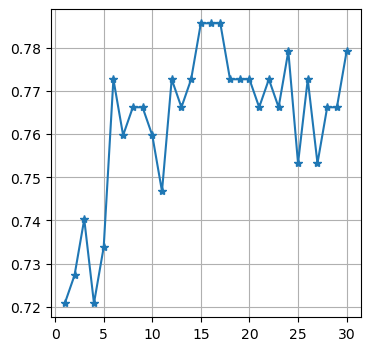

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.plot(range(1,31),accuracy,marker="*")
plt.grid(True)
plt.show()

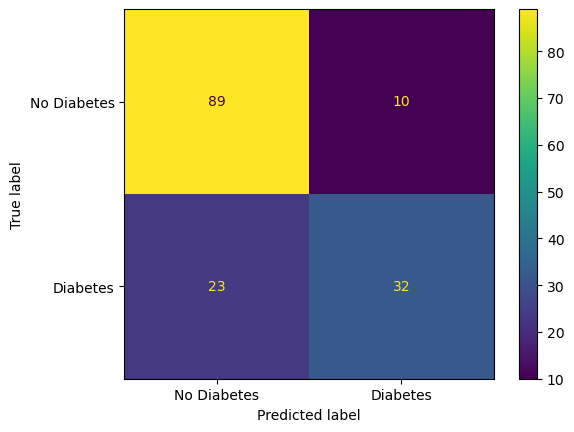

In [26]:
import matplotlib.pyplot as plt
from sklearn import metrics
cm_display=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Diabetes","Diabetes"])
cm_display.plot()
plt.show()